# Real function spaces (non linear)

Author: Remi Delaporte-Mathurin, Jørgen S. Dokken

License: MIT

In this example we will show:
- How to define a submesh on a subset of facets
- How to use the "real" function space on this submesh
- How to solve a problem coupling this real space with the bulk using
  a nonlinear solver.

A circular gas cavity inside a solid domain has an initial partial
pressure $P_b$.
The concentration $u$ on the cavity surface follows Henry's solubility law:
the concentration is proportional to the partial pressure $P_b$.

As particles leave the cavity by solution/diffusion, the partial pressure
starts to decrease - affecting in turn the concentration on the
cavity surface.


## Mathematical formulation
 The problem at hand is:
Find $u \in H^1(\Omega)$ such that

$$
\begin{align}
\Delta u &= 0 \quad \text{in } \Omega, \\
u &= 0 \quad \text{on } \Gamma_1, \\
u &= K P_b \quad \text{on } \Gamma_b,
\end{align}
$$

where $P_b\in \mathbb{R}$ is the partial pressure inside the cavity region.
The temporal evolution of $P_b$ is governed by:

$$
\frac{dP_b}{dt} = \frac{e}{V} \int_{\Gamma_b} -D \nabla u \cdot \mathbf{n} dS
$$


We write the weak formulation with $v$ and $w$ suitable test functions:

$$
\begin{align}
\int_\Omega  \frac{u - u_n}{\Delta t} \cdot v~\mathrm{d}x
+ \int_\Omega \nabla u \cdot \nabla v~\mathrm{d}x &= 0\\
\int_\Omega  \frac{P_b - P_{b_n}}{\Delta t} \cdot w~\mathrm{d}x
&= \frac{e}{V} \int_{\Gamma_b} -D \nabla u \cdot \mathbf{n} \cdot ~w ~\mathrm{d}S.
\end{align}
$$

## Implementation
We start by import the necessary modules
```{admonition} Clickable functions/classes
Note that for the modules imported in this example, you can click on the function/class
name to be redirected to the corresponding documentation page.
```

In [1]:
from mpi4py import MPI
from petsc4py import PETSc
import dolfinx
from dolfinx.fem.petsc import NonlinearProblem
from dolfinx.io import gmsh as gmshio
from dolfinx.plot import vtk_mesh
import numpy as np
from scifem import create_real_functionspace, assemble_scalar
import ufl
import pyvista
import gmsh
import matplotlib as mpl
import matplotlib.pyplot as plt


### Mesh generation
We generate the mesh using GMSH.
For a more detailed explaination of the mesh generation process, see:
https://jsdokken.com/dolfinx-tutorial/chapter2/ns_code2.html#mesh-generation

In [ ]:
import gmsh
import numpy as np
from mpi4py import MPI

gmsh.initialize()

# --- geometry parameters ---
L = 2.0
H = L
c_x = c_y = 0.0
r = 0.05
gdim = 2

mesh_comm = MPI.COMM_WORLD
model_rank = 0

# ========================================
# 1. Geometry
# ========================================
if mesh_comm.rank == model_rank:
    outer = gmsh.model.occ.addDisk(0, 0, 0, L / 2, H / 2, tag=1)
    inner = gmsh.model.occ.addDisk(c_x, c_y, 0, r, r, tag=2)
    fluid = gmsh.model.occ.cut([(gdim, outer)], [(gdim, inner)])
    gmsh.model.occ.synchronize()

# ========================================
# 2. Physical groups
# ========================================
solid_marker = 1
wall_marker = 2
obstacle_marker = 3

if mesh_comm.rank == model_rank:
    volumes = gmsh.model.getEntities(dim=gdim)
    assert len(volumes) == 1
    gmsh.model.addPhysicalGroup(gdim, [volumes[0][1]], solid_marker)
    gmsh.model.setPhysicalName(gdim, solid_marker, "Solid")

    boundaries = gmsh.model.getBoundary(volumes, oriented=False)

    walls = []
    obstacle = []

    for boundary in boundaries:
        # bounding box of this curve
        xmin, ymin, zmin, xmax, ymax, zmax = gmsh.model.getBoundingBox(
            boundary[0], boundary[1]
        )
        extent = max(xmax - xmin, ymax - ymin)

        # inner circle has extent ~2r = 0.1
        # outer ellipse has extent ~L = 2.0
        if extent < 4 * r:
            obstacle.append(boundary[1])
        else:
            walls.append(boundary[1])

    print(f"Walls: {walls}, Obstacle: {obstacle}")  # sanity check

    gmsh.model.addPhysicalGroup(1, walls, wall_marker)
    gmsh.model.setPhysicalName(1, wall_marker, "Walls")
    gmsh.model.addPhysicalGroup(1, obstacle, obstacle_marker)
    gmsh.model.setPhysicalName(1, obstacle_marker, "Obstacle")


# ========================================
# 3. Size field
# ========================================
res_min = r / 2        # was r/3 — slightly coarser near hole
res_max = 0.1 * L      # was 0.1*L — coarser in the bulk

if mesh_comm.rank == model_rank:
    dist_f = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(dist_f, "CurvesList", obstacle)
    gmsh.model.mesh.field.setNumber(dist_f, "Sampling", 100)

    thresh_f = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(thresh_f, "IField", dist_f)
    gmsh.model.mesh.field.setNumber(thresh_f, "LcMin", res_min)
    gmsh.model.mesh.field.setNumber(thresh_f, "LcMax", res_max)
    gmsh.model.mesh.field.setNumber(thresh_f, "DistMin", 2 * r)
    gmsh.model.mesh.field.setNumber(thresh_f, "DistMax", L)

    min_f = gmsh.model.mesh.field.add("Min")
    gmsh.model.mesh.field.setNumbers(min_f, "FieldsList", [thresh_f])
    gmsh.model.mesh.field.setAsBackgroundMesh(min_f)

    gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
    gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
    gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)

# ========================================
# 4. Meshing – all-quad, second order
# ========================================
if mesh_comm.rank == model_rank:
    # gmsh.option.setNumber("Mesh.Algorithm", 8)
    # gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 3)
    # gmsh.option.setNumber("Mesh.RecombineAll", 1)
    # gmsh.option.setNumber("Mesh.Smoothing", 100)

    # NO SubdivisionAlgorithm — it re-subdivides every element,
    # quadrupling the count and producing poor shapes

    gmsh.model.mesh.generate(gdim)

    # # Smooth while still first order
    # gmsh.model.mesh.optimize("Laplace2D")
    # gmsh.model.mesh.optimize("Relocate2D")

    # # Elevate to second order
    # gmsh.model.mesh.setOrder(2)

    # # Optimise high-order node placement
    # gmsh.model.mesh.optimize("HighOrder")

# ========================================
# 5. Import into DOLFINx
# ========================================
mesh_data = gmshio.model_to_mesh(gmsh.model, mesh_comm, model_rank, gdim=gdim)
mesh = mesh_data.mesh
assert mesh is not None
assert mesh_data.facet_tags is not None
ft = mesh_data.facet_tags
ft.name = "Facet markers"

gmsh.finalize()

Walls: [3], Obstacle: [2]                                                                                                                      
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 2 (Ellipse)
Info    : [ 60%] Meshing curve 3 (Ellipse)
Info    : Done meshing 1D (Wall 0.00115978s, CPU 0.001s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00356582s, CPU 0.003647s)
Info    : 306 nodes 614 elements


In [3]:
walls

[3]

Next we inspect the grid and markers

In [4]:
pyvista.set_jupyter_backend("html")

tdim = mesh.topology.dim

mesh.topology.create_connectivity(tdim, tdim)
topology, cell_types, geometry = vtk_mesh(mesh, tdim)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

plotter = pyvista.Plotter(shape=(1, 2))
plotter.subplot(0, 0)
plotter.add_mesh(grid, show_edges=True)
plotter.view_xy()

fdim = tdim - 1
mesh.topology.create_connectivity(fdim, tdim)
facet_topology, facet_cell_types, facet_x = vtk_mesh(mesh, fdim, ft.indices)

facet_grid = pyvista.UnstructuredGrid(
    facet_topology, facet_cell_types, facet_x)
facet_grid.cell_data["Facet Marker"] = ft.values
facet_grid.set_active_scalars("Facet Marker")
plotter.subplot(0, 1)
plotter.view_xy()
plotter.add_mesh(facet_grid, show_edges=True)
plotter.link_views()
if not pyvista.OFF_SCREEN:
    plotter.show()
else:
    figure = plotter.screenshot("mesh.png")


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

### Submeshes and real function space
We create two functionspaces `V` and `R` for $u$ and $P_b$, respectively.
The partial pressure is a single, constant value, that should be defined
on the interface between the cavity and the fluid domain.
This is a "real" function space, that has only one degree of freedom,
and is not associated with any mesh entity.
We can create such a function space using the helper function
{py:func}`scifem.create_real_functionspace`.
However, first we will create a submesh on the cavity surface,
as this is where the partial pressure is defined.

In [5]:
cavity_surface, cavity_map, _, _ = dolfinx.mesh.create_submesh(
    mesh, ft.dim, ft.find(obstacle_marker))
R = create_real_functionspace(cavity_surface)

We will solve this as a strongly coupled problem.
To do so, we use {py:class}`ufl.MixedFunctionSpace` test functions
that respect the block structure of the problem.

In [6]:
V = dolfinx.fem.functionspace(mesh, ("Lagrange", 1))
W = ufl.MixedFunctionSpace(V, R)

## Variational formulation and nonlinear solver
We then create appropriate functions and test functions:

In [7]:
u = dolfinx.fem.Function(V)
u_n = dolfinx.fem.Function(V)
pressure = dolfinx.fem.Function(R)
pressure_n = dolfinx.fem.Function(R)
v, pressure_v = ufl.TestFunctions(W)

Let's define the problems constants:

In [8]:
dt = dolfinx.fem.Constant(mesh, 0.05)
A = dolfinx.fem.Constant(mesh, 2.0)
K_S = dolfinx.fem.Constant(mesh, 1/(8*np.pi*A.value*r**2))
# e = dolfinx.fem.Constant(mesh, 2.0)
# volume = dolfinx.fem.Constant(mesh, 40.0)
# u_out = dolfinx.fem.Constant(mesh, 0.0)

In [9]:
t = dolfinx.fem.Constant(mesh, 0.0)
x = ufl.SpatialCoordinate(mesh)
u_e = dolfinx.fem.Function(V)

def u_exact(t, x):
    return 2 * ((x[0] - c_x)**2  + (x[1] - c_y)**2) + t

def dudt(t, x):
    return 1

u_e.interpolate(lambda x: u_exact(t, x))

In [10]:
u_n.interpolate(lambda x: u_exact(0.0, x))
P_b_initial = dolfinx.fem.Constant(cavity_surface, u_exact(0.0, [r, 0])/K_S.value)


In [11]:
f = 7#dudt(t, x) + ufl.div(ufl.grad(u_e))
f

7

```{note}
If `dt` is too large, the problem becomes unstable
```


We can now define the initial condition and boundary conditions:

In [12]:
pressure_ini_expr = dolfinx.fem.Expression(
    P_b_initial, R.element.interpolation_points
)
pressure_n.interpolate(pressure_ini_expr)
pressure.x.array[:] = pressure_n.x.array[:]

dofs_boundary = dolfinx.fem.locate_dofs_topological(
    V, fdim, ft.find(wall_marker))
dofs_bubble = dolfinx.fem.locate_dofs_topological(
    V, fdim, ft.find(obstacle_marker))

bc_boundary = dolfinx.fem.dirichletbc(u_e, dofs_boundary)

Next we define the variational formulation and call
{py:func}`ufl.extract_blocks` to form the blocked formulations:

In [13]:
# For the boundary condition coupling pressure and concentration,
# we use a Nitsche formulation,
# see: https://jsdokken.com/dolfinx-tutorial/chapter1/nitsche.html
# for more details about Nitsche's method.

n = ufl.FacetNormal(mesh)
H = dolfinx.fem.functionspace(cavity_surface, ("DG", 0))
h = dolfinx.fem.Function(H)
h.x.array[:] = cavity_surface.h(
    ft.dim, np.arange(len(ft.find(obstacle_marker)), dtype=np.int32))
flux = ufl.inner(ufl.grad(u), n)

ds = ufl.Measure("ds", domain=mesh, subdomain_data=ft)

g = K_S * pressure
alpha = dolfinx.fem.Constant(mesh, 10.0)

F = ufl.inner(u - u_n, v) * ufl.dx
F += dt * ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
F += dt * ufl.inner(f, v) * ufl.dx
F += ufl.inner(pressure - pressure_n, pressure_v) * ds(3)
F += dt * ufl.inner(A * flux, pressure_v) * ds(3)
F -= ufl.dot(ufl.dot(n, ufl.grad(u)), v) * ds(3)
F -= -ufl.inner(u - g, ufl.dot(n, ufl.grad(v))) * ds(3)
F += alpha / h * ufl.inner(u - g, v) * ds(3)

forms = ufl.extract_blocks(F)


We can now create a
{py:class}`nonlinear solver<dolfinx.fem.petsc.NonlinearProblem>`
with the blocked formulations and the functions `u` and `pressure` as a list:

In [14]:
solver = NonlinearProblem(
    forms,
    [u, pressure],
    bcs=[bc_boundary],
    petsc_options_prefix="bubble",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "snes_error_if_not_converged": True,
        "ksp_error_if_not_converged": True,
        "snes_monitor": None,
    },
    entity_maps=[cavity_map]
)

Set up transient pyvista visualisation:

In [15]:
grid = pyvista.UnstructuredGrid(*vtk_mesh(V))

plotter = pyvista.Plotter()
plotter.open_gif("u_time.gif", fps=10)

grid.point_data["u"] = u.x.array
warped = grid.warp_by_scalar("u", factor=100)

viridis = mpl.colormaps.get_cmap("viridis").resampled(25)
sargs = dict(
    title_font_size=25,
    label_font_size=20,
    fmt="%.2e",
    color="black",
    position_x=0.1,
    position_y=0.8,
    width=0.8,
    height=0.1,
)

renderer = plotter.add_mesh(
    warped,
    show_edges=True,
    lighting=False,
    cmap=viridis,
    scalar_bar_args=sargs,
    # clim=[0, float(K_S.value * P_b_initial.value)],
    clim=[0, 10],
)

Time stepping loop:

In [16]:
t_final = 5

times = []
all_pressures = []
outgassing_fluxes = []

par_print = PETSc.Sys.Print
while t.value < t_final:
    t.value += dt.value
    times.append(float(t))
    par_print(f"Time: {t.value:.2f} / {t_final:.2f}")

    u_e.interpolate(lambda x: u_exact(t.value, x))
    # u_e.interpolate(lambda x: np.full_like(x[0], u_exact(t.value, x)))

    # Solve the problem
    (u, pressure) = solver.solve()

    # Update previous solution
    u_n.x.array[:] = u.x.array[:]
    pressure_n.x.array[:] = pressure.x.array[:]

    # Update bubble BC
    all_pressures.append(pressure.x.array[0].copy())

    # Update plot
    new_warped = grid.warp_by_scalar("u", factor=0.1)
    warped.points[:, :] = new_warped.points
    warped.point_data["u"][:] = u.x.array
    plotter.write_frame()

    # compute outgassing flux
    outgassing_flux = mesh.comm.allreduce(
        -assemble_scalar(flux * ds(2)), op=MPI.SUM)
    outgassing_fluxes.append(outgassing_flux)
plotter.close()

Time: 0.05 / 5.00
  0 SNES Function norm 7.695597613608e+00
  1 SNES Function norm 7.581012024184e-16
Time: 0.10 / 5.00
  0 SNES Function norm 1.890650202320e-01
  1 SNES Function norm 8.623079328753e-16
Time: 0.15 / 5.00
  0 SNES Function norm 1.889167925425e-01
  1 SNES Function norm 7.261382854368e-16
Time: 0.20 / 5.00
  0 SNES Function norm 1.888471452334e-01
  1 SNES Function norm 1.365953016969e-15
Time: 0.25 / 5.00
  0 SNES Function norm 1.888013937675e-01
  1 SNES Function norm 1.169149692123e-15
Time: 0.30 / 5.00
  0 SNES Function norm 1.887684026877e-01
  1 SNES Function norm 8.463635192071e-16
Time: 0.35 / 5.00
  0 SNES Function norm 1.887437304142e-01
  1 SNES Function norm 1.232756707158e-15
Time: 0.40 / 5.00
  0 SNES Function norm 1.887249533774e-01
  1 SNES Function norm 1.084153942709e-15
Time: 0.45 / 5.00
  0 SNES Function norm 1.887105278911e-01
  1 SNES Function norm 1.283713986492e-15
Time: 0.50 / 5.00
  0 SNES Function norm 1.886993861795e-01
  1 SNES Function norm

![title](u_time.gif)
We see that, as expected, the partial pressure $P_b$ decreases with time.

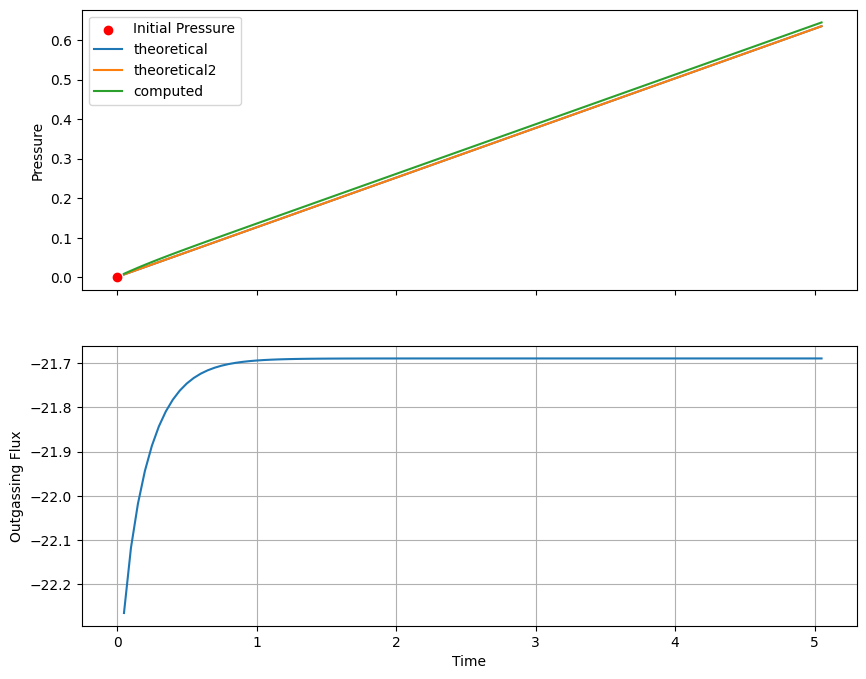

In [17]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axs[0].scatter([0], [P_b_initial.value], color="red", label="Initial Pressure")
# axs[0].plot(times,  4 * np.pi *A.value * np.array(times)**2 * r**2, label="theoretical")
axs[0].plot(times,  u_exact(np.array(times), x=[r, 0])/K_S.value, label="theoretical")
axs[0].plot(times,  P_b_initial.value + 8*np.pi * A.value * r**2 * np.array(times), label="theoretical2")
axs[0].plot(times, all_pressures, label="computed")
axs[0].set_ylabel("Pressure")
axs[0].legend()
# axs[0].set_ylim(bottom=0)

axs[1].plot(times, outgassing_fluxes)

axs[1].set_ylabel("Outgassing Flux")
# axs[1].set_ylim(bottom=0)

plt.xlabel("Time")
plt.grid(True)
plt.show()